In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#1. 패키지 불러오기

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import folium
from folium import plugins
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 한글 깨짐설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree       
Reading state information... Done
fonts-nanum is already the newest version (20180306-3).
0 upgraded, 0 newly installed, 0 to remove and 23 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 10 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

#2. 데이터 불러오기

In [4]:
path = '/content/drive/MyDrive/데이터분석프로젝트/강서구 공모전/'
df_da = pd.read_csv(path+'데이터/장애인+현황(장애유형별_동별)_20230315183047.csv')
df_p = pd.read_csv(path+'데이터/주민등록인구(연령별_동별)_20230315213812.csv')
display(df_da.head())
display(df_p.head())

,동별(1),동별(2),동별(3),성별(1),장애유형별(1),장애유형별(2),2021
0,합계,강서구,염창동,남자,합계,지체,259
1,합계,강서구,염창동,남자,합계,뇌병변,56
2,합계,강서구,염창동,남자,합계,시각,69
3,합계,강서구,염창동,여자,합계,지체,173
4,합계,강서구,염창동,여자,합계,뇌병변,47


,동별(1),동별(2),동별(3),항목,2021
0,동별(1),동별(2),동별(3),항목,계
1,합계,강서구,염창동,계,41764
2,합계,강서구,등촌1동,계,24436
3,합계,강서구,등촌2동,계,20423
4,합계,강서구,등촌3동,계,30714


#3. 데이터 전처리

In [5]:
gs_disable = df_da.drop(['동별(1)','동별(2)','성별(1)','장애유형별(1)'], axis=1)
gs_pop = df_p.drop(['동별(1)','동별(2)','항목'], axis=1)[1:]
display(gs_disable.head(3))
display(gs_pop.head(3))

,동별(3),장애유형별(2),2021
0,염창동,지체,259
1,염창동,뇌병변,56
2,염창동,시각,69


,동별(3),2021
1,염창동,41764
2,등촌1동,24436
3,등촌2동,20423


In [6]:
gs_disable.columns = ['행정동','장애유형','장애인인구수']
gs_pop.columns = ['행정동','인구수']

display(gs_disable.head(3))
display(gs_pop.head(3))

,행정동,장애유형,장애인인구수
0,염창동,지체,259
1,염창동,뇌병변,56
2,염창동,시각,69


,행정동,인구수
1,염창동,41764
2,등촌1동,24436
3,등촌2동,20423


In [7]:
gs_pop['인구수'] = gs_pop['인구수'].astype('float')

In [8]:
# 강서구 전체 장애인 비율
round(gs_disable['장애인인구수'].sum() / gs_pop['인구수'].sum(),2)

0.03

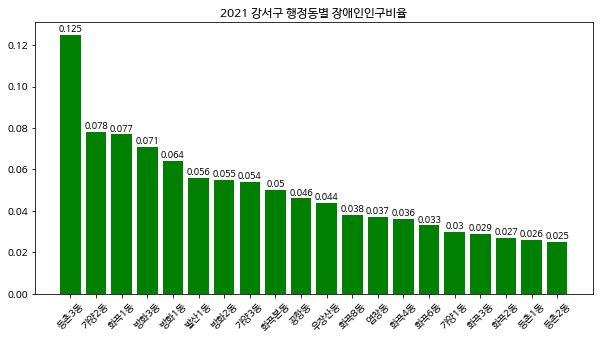

In [9]:
da_cnt = pd.DataFrame(gs_disable.groupby('행정동')['장애인인구수'].sum().sort_values(ascending=False))
da_ratio = round(da_cnt / gs_disable['장애인인구수'].sum(),3)
plt.figure(figsize=(10,5))
bar = plt.bar(da_ratio.index, da_ratio['장애인인구수'], color='green')
# 숫자 넣는 부분
for i, v in enumerate(da_ratio.index):
    plt.text(v, da_ratio['장애인인구수'][i],da_ratio['장애인인구수'][i],
             fontsize=9,
             horizontalalignment='center',
             verticalalignment='bottom')
plt.title('2021 강서구 행정동별 장애인인구비율')
plt.xticks(rotation=45)
plt.show()

- 강서구 장애인인구 중 12%가 등촌3동에 거주하고 있음을 알 수 있다.

# 4.데이터 통합

In [10]:
gs_pop = gs_pop.set_index('행정동')
gs_pop_da = pd.concat([da_cnt,gs_pop], axis=1)
gs_pop_da.head()

,장애인인구수,인구수
행정동,,
등촌3동,2203,30714.0
가양2동,1368,14109.0
화곡1동,1357,52770.0
방화3동,1248,22924.0
방화1동,1126,43181.0


In [11]:
gs_pop_da['인구수'] = gs_pop_da['인구수'].astype(int)

In [12]:
gs_pop_da['장애인비율'] = round(gs_pop_da['장애인인구수'] / gs_pop_da['인구수'],3)
gs_pop_da.sort_values(by='장애인비율', ascending=False)

,장애인인구수,인구수,장애인비율
행정동,,,
가양2동,1368,14109,0.097
등촌3동,2203,30714,0.072
가양3동,955,15138,0.063
방화3동,1248,22924,0.054
방화2동,976,23656,0.041
화곡4동,639,20820,0.031
발산1동,991,36572,0.027
화곡8동,662,24789,0.027
화곡1동,1357,52770,0.026


각 행정동 별 전체 인구 대비 장애인 인구 의 비율은 가양 2동, 등촌 3동, 가양 3동 순으로 높은 것을 확인할 수 있다.

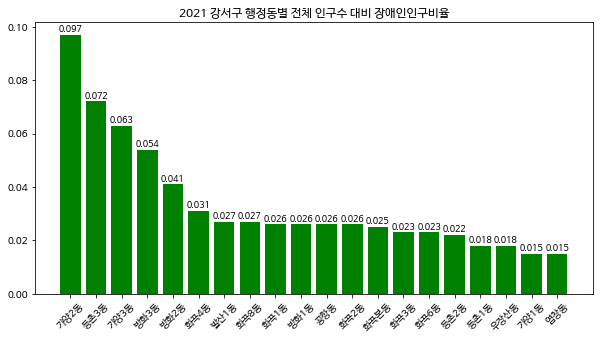

In [13]:
plt.figure(figsize=(10,5))
gs_pop_da_sort  = gs_pop_da.sort_values(by='장애인비율',ascending=False)
bar = plt.bar(gs_pop_da_sort.index, gs_pop_da_sort['장애인비율'], color='green')
# 숫자 넣는 부분
for i, v in enumerate(gs_pop_da_sort.index):
    plt.text(v, gs_pop_da_sort['장애인비율'][i],gs_pop_da_sort['장애인비율'][i],
             fontsize=9,
             horizontalalignment='center',
             verticalalignment='bottom')
plt.title('2021 강서구 행정동별 전체 인구수 대비 장애인인구비율')
plt.xticks(rotation=45)
plt.show()

In [ ]:
gs_pop_da = gs_pop_da.reset_index()
gs_pop_da.head()

,행정동,장애인인구수,인구수,장애인비율
0,등촌3동,2203,30714,0.072
1,가양2동,1368,14109,0.097
2,화곡1동,1357,52770,0.026
3,방화3동,1248,22924,0.054
4,방화1동,1126,43181,0.026


In [ ]:
# gs_pop_da.to_csv(path+'/데이터/전처리_데이터/강서구_장애인인구수.csv', index=False) # 전처리한 데이터 내보내기

In [ ]:
# 장애인 인구수 데이터 정규화
gs_pop_da['장애인비율_정규화'] = (gs_pop_da['장애인비율'] - gs_pop_da['장애인비율'].min()) / (gs_pop_da['장애인비율'].max() - gs_pop_da['장애인비율'].min() )
gs_pop_da

,행정동,장애인인구수,인구수,장애인비율,장애인비율_정규화
0,등촌3동,2203,30714,0.072,0.695122
1,가양2동,1368,14109,0.097,1.000000
2,화곡1동,1357,52770,0.026,0.134146
3,방화3동,1248,22924,0.054,0.475610
4,방화1동,1126,43181,0.026,0.134146
5,발산1동,991,36572,0.027,0.146341
6,방화2동,976,23656,0.041,0.317073
7,가양3동,955,15138,0.063,0.585366
8,화곡본동,877,34612,0.025,0.121951
9,공항동,816,31483,0.026,0.134146


In [ ]:
# gs_pop_da.to_csv(path+'/데이터/전처리_데이터/강서구_장애인인구수_정규화추가.csv', index=False) # 전처리한 데이터 내보내기